# Label population + balanced split
Counts per-class pixels/presence for every mask, then **overwrites `splits.txt`** with a train/val/test split whose label distribution matches the whole dataset. Split stays by **patient id** (no leakage).

In [1]:
import os, shutil, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from dataset import LBL_DIR, SPLITS

NAMES = ["Background","Tooth","Alveolar Bone","Root Canal Filling","Denture Crown","Implant",
         "Dental Fillings","Pulp","Orthodontic Devices","Apical Periodontitis"]
FRAC = {"train": 0.8, "val": 0.1, "test": 0.1}   # target share of each label per split

In [2]:
# 1) per-image class pixel counts (cached: delete label_counts.csv to recount)
CSV = "label_counts.csv"
def count(p):
    a = np.array(Image.open(os.path.join(LBL_DIR, p)))
    return [p[:-4], *np.bincount(a.ravel(), minlength=10)[:10].tolist()]
if os.path.exists(CSV):
    df = pd.read_csv(CSV, dtype={"stem": str})
else:
    files = sorted(f for f in os.listdir(LBL_DIR) if f.endswith(".png"))
    with ThreadPoolExecutor(8) as ex:
        df = pd.DataFrame(list(ex.map(count, files)), columns=["stem", *range(10)])
    df.to_csv(CSV, index=False)
df.columns = ["stem", *range(10)]
df["patient"] = df.stem.str.split("-").str[0]
print(len(df), "images,", df.patient.nunique(), "patients")

5000 images, 2572 patients


,class,pixels,pixel_%,images_with,image_%
0,Background,1575648272,16.413,5000,100.0
1,Tooth,4221769671,43.977,4996,99.9
2,Alveolar Bone,3203712965,33.372,4997,99.9
3,Root Canal Filling,98415766,1.025,1943,38.9
4,Denture Crown,125852586,1.311,577,11.5
5,Implant,4011574,0.042,20,0.4
6,Dental Fillings,99821098,1.040,1748,35.0
7,Pulp,236689952,2.466,4640,92.8
8,Orthodontic Devices,3136016,0.033,39,0.8
9,Apical Periodontitis,30942100,0.322,670,13.4


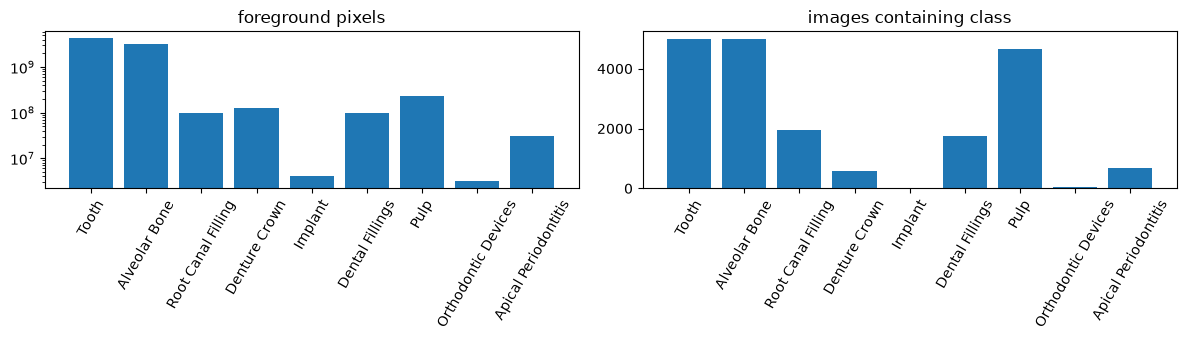

In [3]:
# 2) whole-dataset population
pix = df[list(range(10))].sum()
pres = (df[list(range(10))] > 0).sum()
pop = pd.DataFrame({"class": NAMES, "pixels": pix.values, "pixel_%": (100*pix/pix.sum()).round(3),
                    "images_with": pres.values, "image_%": (100*pres/len(df)).round(1)})
display(pop)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(NAMES[1:], pix.values[1:]); ax[0].set_title("foreground pixels"); ax[0].set_yscale("log")
ax[1].bar(NAMES[1:], pres.values[1:]); ax[1].set_title("images containing class")
for a in ax: a.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

In [4]:
# 3) stratified patient-level split: greedy, rare classes first.
# Per patient feature = [n_images, foreground pixels/class, image-presence/class]; each column is
# scaled so its dataset total = 1, then each patient goes to the split whose running share
# is furthest below target (minimises squared error vs FRAC).
fg = list(range(1, 10))
feat = pd.concat([pd.Series(1, index=df.index, name="n"),
                  df[fg].rename(columns=lambda c: f"px{c}"),
                  (df[fg] > 0).astype(int).rename(columns=lambda c: f"pr{c}")], axis=1)
P = feat.groupby(df.patient).sum().astype(float)
P = P / P.sum()
order = P.drop(columns="n").max(axis=1).sort_values(ascending=False).index   # patients holding big chunks of a class first
acc = {s: np.zeros(P.shape[1]) for s in FRAC}
assign = {}
for pid in order:
    v = P.loc[pid].values
    # cost = squared relative deviation of every split's share from its target, after adding v to split s
    cost = {s: sum((((acc[s2] + (v if s2 == s else 0)) / f2 - 1.0) ** 2).sum() for s2, f2 in FRAC.items()) for s in FRAC}
    best = min(cost, key=cost.get)
    acc[best] += v; assign[pid] = best
# local search: re-place each patient (removed first) until nothing moves
def total(): return sum((((acc[s] / f) - 1.0) ** 2).sum() for s, f in FRAC.items())
for _ in range(50):
    moved = 0
    for pid in order:
        v = P.loc[pid].values
        acc[assign[pid]] -= v
        cost = {s: sum((((acc[s2] + (v if s2 == s else 0)) / f2 - 1.0) ** 2).sum() for s2, f2 in FRAC.items()) for s in FRAC}
        best = min(cost, key=cost.get)
        moved += best != assign[pid]
        acc[best] += v; assign[pid] = best
    if not moved: break
print("cost", round(total(), 4))
df["split"] = df.patient.map(assign)

cost 0.7439


In [5]:
# 4) check: each split's share of every label vs target
rows = []
for s in FRAC:
    d = df[df.split == s]
    rows.append({"split": s, "images_%": round(100*len(d)/len(df), 1),
                 **{NAMES[c]+" px%": round(100*d[c].sum()/df[c].sum(), 1) for c in fg},
                 **{NAMES[c]+" img%": round(100*(d[c] > 0).sum()/(df[c] > 0).sum(), 1) for c in fg}})
chk = pd.DataFrame(rows).set_index("split").T
display(chk)
assert not (set(df[df.split=="train"].patient) & set(df[df.split=="val"].patient)), "leak"
assert not (set(df[df.split=="train"].patient) & set(df[df.split=="test"].patient)), "leak"
assert not (set(df[df.split=="val"].patient) & set(df[df.split=="test"].patient)), "leak"
print("max |deviation| from target (pp):",
      max(abs(chk.loc[i, s] - 100*FRAC[s]) for i in chk.index[1:] for s in FRAC))

split,train,val,test
images_%,80.0,10.0,10.0
Tooth px%,80.0,10.0,10.0
Alveolar Bone px%,80.0,10.0,10.0
Root Canal Filling px%,79.7,10.2,10.1
Denture Crown px%,79.8,10.1,10.1
Implant px%,73.4,11.4,15.3
Dental Fillings px%,79.8,10.1,10.1
Pulp px%,79.8,10.1,10.1
Orthodontic Devices px%,74.9,11.0,14.1
Apical Periodontitis px%,79.9,10.2,10.0


max |deviation| from target (pp): 6.599999999999994


In [6]:
# 5) overwrite splits.txt (old one kept as splits.txt.bak)
if os.path.exists(SPLITS): shutil.copy(SPLITS, SPLITS + ".bak")
with open(SPLITS, "w") as f:
    for s, sp in zip(df.stem, df.split): f.write(f"{s} {sp}" + chr(10))
print("wrote", SPLITS, df.split.value_counts().to_dict())

wrote C:\Users\pierre bassily\projects\ENDO_xray_ai\segmentation_model\splits.txt {'train': 3998, 'val': 501, 'test': 501}
